In [1]:
2+2

4

In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
load_dotenv()

model=ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.3,
    max_completion_tokens=200
)

In [3]:
class State(TypedDict):
    topic:str
    joke:str
    joke_explanation:str


In [4]:
def generate_joke(state:State):
    response=model.invoke(f"generate a joke on the topic: {state['topic']}")

    return {
        "joke":response.content
    }

def generate_explanation(state:State):
    response=model.invoke(f"Give a sort explanation on the the joke: {state['joke']}")
    return {
        "joke_explanation":response.content
    }

In [5]:
graph=StateGraph(State)
graph.add_node("generate_joke_node",generate_joke)
graph.add_node("generate_explanation_node",generate_explanation)

graph.add_edge(START,"generate_joke_node")
graph.add_edge("generate_joke_node","generate_explanation_node")
graph.add_edge("generate_explanation_node",END)



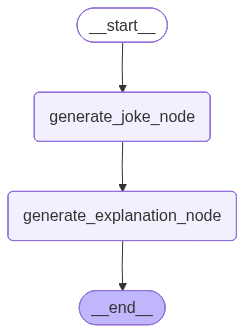

In [6]:
checkpointer=InMemorySaver()
config={
    "configurable":{"thread_id":2}
}

workflow=graph.compile(checkpointer=checkpointer)
workflow

In [7]:
initial_state={
    "topic":"Pizza"
}

response=workflow.invoke(initial_state,config=config)
response

{'topic': 'Pizza',
 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough! 🍕",
 'joke_explanation': 'The joke plays on a double meaning of the word "dough." In one sense, "dough" refers to the mixture used to make pizza, which is a key part of a pizza maker\'s job. In another sense, "dough" is a slang term for money. So, the punchline suggests that the pizza maker went broke because he wasn\'t making enough money (dough) while also hinting at his inability to produce enough pizza dough. The clever wordplay creates a humorous twist!'}

In [8]:
workflow.get_state(config=config)

StateSnapshot(values={'topic': 'Pizza', 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough! 🍕", 'joke_explanation': 'The joke plays on a double meaning of the word "dough." In one sense, "dough" refers to the mixture used to make pizza, which is a key part of a pizza maker\'s job. In another sense, "dough" is a slang term for money. So, the punchline suggests that the pizza maker went broke because he wasn\'t making enough money (dough) while also hinting at his inability to produce enough pizza dough. The clever wordplay creates a humorous twist!'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f83d1-2124-6456-8002-f731063b6cbe'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-23T09:22:42.836571+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f83d1-0dc5-66da-8001-5a41353c0712'}}, tasks=(), interrupts=())

In [9]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'topic': 'Pizza', 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough! 🍕", 'joke_explanation': 'The joke plays on a double meaning of the word "dough." In one sense, "dough" refers to the mixture used to make pizza, which is a key part of a pizza maker\'s job. In another sense, "dough" is a slang term for money. So, the punchline suggests that the pizza maker went broke because he wasn\'t making enough money (dough) while also hinting at his inability to produce enough pizza dough. The clever wordplay creates a humorous twist!'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f83d1-2124-6456-8002-f731063b6cbe'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-23T09:22:42.836571+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0f83d1-0dc5-66da-8001-5a41353c0712'}}, tasks=(), interrupts=()),
 StateSnapshot